# Subject-Generalising DeFOG Episode Detector

## Goal

Predict whether freezing of gait is occurring at each timestamp for
subjects that never appear in training. Event type is retained as a
low-weight auxiliary output, while episode timing is the primary result.

### Key assumptions

- `defog_metadata.csv` is the authoritative recording-to-subject mapping.
- The intended deployment is inference on a previously unseen subject.
- Ground-truth event labels are unavailable at prediction time, so no
  target or target-derived rolling count is used as a feature.

## Setup

In [ ]:
from pathlib import Path
import sys
import gc
import importlib
import numpy as np

print(f"Python executable: {sys.executable}")
print(f"NumPy version: {np.__version__}")
if int(np.__version__.split(".")[0]) >= 2:
    raise RuntimeError(
        "This notebook requires NumPy 1.26.x. Select the "
        "'Dissertation FoG (.venv)' kernel and restart the notebook."
    )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src" / "fog_pipeline.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

importlib.invalidate_caches()
import fog_pipeline as _fog_pipeline
_fog_pipeline = importlib.reload(_fog_pipeline)

from fog_pipeline import (
    ANY_FOG_COLUMN,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    align_binary_predictions,
    assert_subject_disjoint,
    evaluate_episode_predictions,
    load_recordings,
    prepare_tabular_splits,
    select_episode_threshold,
    split_by_subject,
    split_summary,
)

RANDOM_STATE = 42
WINDOW_SIZE = 5
EDA_SAMPLE_SIZE = 200_000
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 20
BATCH_SIZE = 4096
RUN_TRAINING = True
EPISODE_IOU_THRESHOLD = 0.25
# No temporal smoothing is imposed without validation evidence.
MERGE_GAP_SECONDS = 0.0
MIN_PREDICTED_EPISODE_SECONDS = 0.0
# Set a small integer for a quick smoke test, or None for the full dataset.
MAX_RECORDINGS = None
# Bounded smoke tests may not contain every rare label; full runs must.
REQUIRE_ALL_TARGETS = MAX_RECORDINGS is None

sns.set_theme(style="whitegrid", context="notebook")

Python executable: d:\Dissertation\.venv\Scripts\python.exe
NumPy version: 1.26.4


## Data — load identities before concatenation

In [12]:
raw_data = load_recordings(
    recordings_dir=PROJECT_ROOT / "data" / "raw" / "train" / "defog",
    metadata_path=PROJECT_ROOT / "data" / "metadata" / "defog_metadata.csv",
    limit_recordings=MAX_RECORDINGS,
    filter_valid_task=True,
)
SAMPLING_RATE_HZ = 100.0
raw_data.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,AnyFoG,RecordingId,Subject
0,1000,-0.970018,0.061626,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
1,1001,-0.984375,0.044497,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
2,1002,-0.984375,0.029016,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
3,1003,-0.984375,0.015625,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35
4,1004,-0.984670,0.015330,-0.265625,0,0,0,True,True,0,02ea782681,ae2d35


### Dataset overview and class balance

,dataset_overview
rows,4090530
recordings,91
subjects_or_file_groups,38
time_min,1000
time_max,414387


,missing_values
Time,0
AccV,0
AccML,0
AccAP,0
AnyFoG,0
StartHesitation,0
Turn,0
Walking,0
RecordingId,0
Subject,0


,count,mean,std,min,1%,25%,50%,75%,99%,max
Time,4090530.0,91125.361824,70259.157136,1000.000000,1449.000000,35529.000000,76822.000000,129562.000000,325532.710000,414387.000000
AccV,4090530.0,-0.934946,0.107224,-6.024701,-1.265625,-0.985271,-0.939239,-0.886963,-0.664778,4.458364
AccML,4090530.0,-0.001229,0.140118,-2.115008,-0.357178,-0.084661,0.000000,0.092481,0.323602,4.524038
AccAP,4090530.0,-0.225780,0.244468,-5.118650,-0.750000,-0.363481,-0.250000,-0.113236,0.525120,4.388132
AnyFoG,4090530.0,0.167667,0.373570,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
StartHesitation,4090530.0,0.000122,0.011055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Turn,4090530.0,0.143460,0.350542,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
Walking,4090530.0,0.024084,0.153311,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000


,rows_per_recording
count,91.000000
mean,44950.879121
std,24171.785040
min,8872.000000
25%,29555.500000
50%,39442.000000
75%,51773.000000
max,142610.000000


,positive_rows,prevalence_percent
AnyFoG,685847,16.766703
StartHesitation,500,0.012223
Turn,586829,14.346038
Walking,98518,2.408441


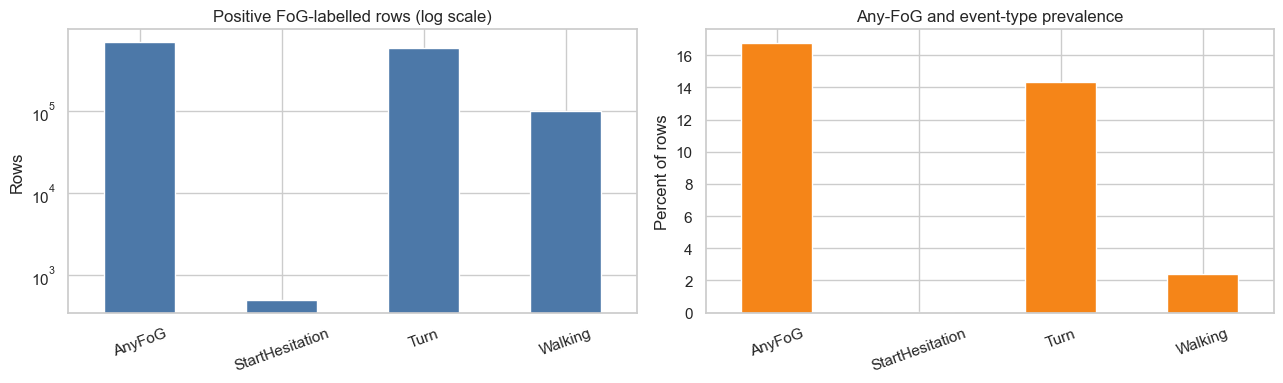

In [13]:
overview = pd.Series(
    {
        "rows": len(raw_data),
        "recordings": raw_data["RecordingId"].nunique(),
        "subjects_or_file_groups": raw_data["Subject"].nunique(),
        "time_min": raw_data["Time"].min(),
        "time_max": raw_data["Time"].max(),
    },
    name="dataset_overview",
)
display(overview.to_frame())

missing_summary = raw_data[
    [
        "Time",
        *FEATURE_COLUMNS[:3],
        ANY_FOG_COLUMN,
        *TARGET_COLUMNS,
        "RecordingId",
        "Subject",
    ]
].isna().sum().rename("missing_values")
display(missing_summary.to_frame())

numeric_summary = raw_data[
    ["Time", *FEATURE_COLUMNS[:3], ANY_FOG_COLUMN, *TARGET_COLUMNS]
].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
display(numeric_summary)

recording_lengths = raw_data.groupby("RecordingId", observed=True).size()
display(
    recording_lengths.describe().rename("rows_per_recording").to_frame()
)

event_columns = [ANY_FOG_COLUMN, *TARGET_COLUMNS]
event_summary = pd.DataFrame(
    {
        "positive_rows": raw_data.loc[:, event_columns].sum(),
        "prevalence_percent": raw_data.loc[:, event_columns].mean() * 100,
    }
)
display(event_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
event_summary["positive_rows"].plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_yscale("log")
axes[0].set_title("Positive FoG-labelled rows (log scale)")
axes[0].set_ylabel("Rows")
event_summary["prevalence_percent"].plot.bar(ax=axes[1], color="#f58518")
axes[1].set_title("Any-FoG and event-type prevalence")
axes[1].set_ylabel("Percent of rows")
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Representative sensor and event window

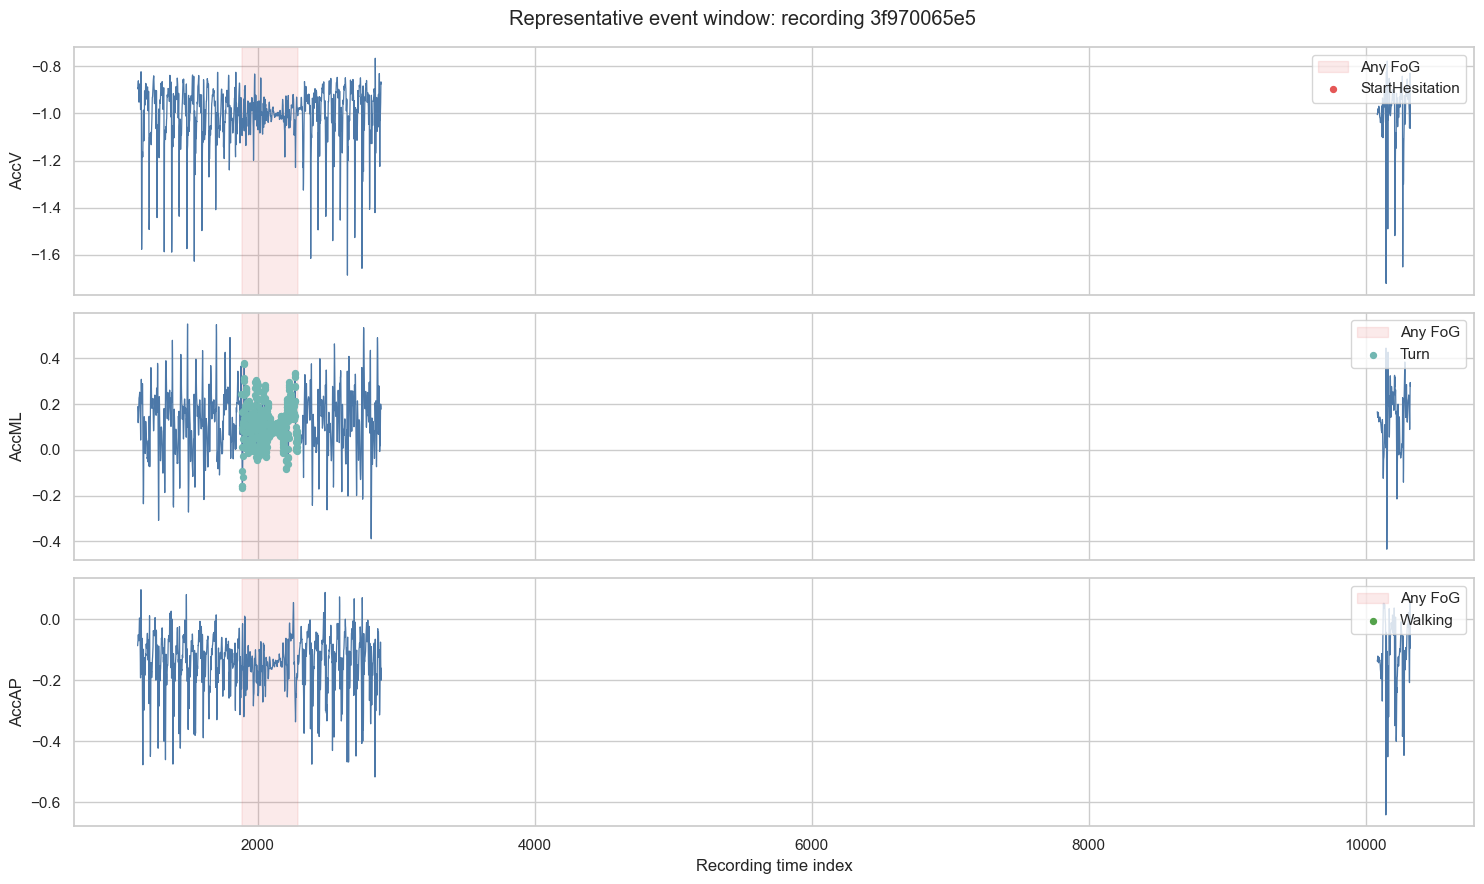

In [14]:
recording_event_totals = raw_data.groupby(
    "RecordingId", observed=True
)[list(TARGET_COLUMNS)].sum()
sample_recording_id = recording_event_totals.sum(axis=1).idxmax()
sample_recording = raw_data.loc[
    raw_data["RecordingId"] == sample_recording_id
].sort_values("Time", kind="stable")

event_positions = np.flatnonzero(
    sample_recording.loc[:, TARGET_COLUMNS].any(axis=1).to_numpy()
)
centre = int(event_positions[0]) if len(event_positions) else len(sample_recording) // 2
window_start = max(0, centre - 750)
window_end = min(len(sample_recording), centre + 1250)
plot_window = sample_recording.iloc[window_start:window_end]

sensor_event_pairs = [
    ("AccV", "StartHesitation", "#e45756"),
    ("AccML", "Turn", "#72b7b2"),
    ("AccAP", "Walking", "#54a24b"),
]
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for axis, (sensor, target, colour) in zip(axes, sensor_event_pairs):
    sensor_values = plot_window[sensor].copy()
    positive_time_steps = plot_window["Time"].diff().dropna()
    positive_time_steps = positive_time_steps.loc[positive_time_steps > 0]
    typical_step = float(positive_time_steps.median()) if len(positive_time_steps) else 1.0
    sensor_values.loc[plot_window["Time"].diff() > 5 * typical_step] = np.nan
    axis.plot(plot_window["Time"], sensor_values, linewidth=0.9, color="#4c78a8")
    axis.fill_between(
        plot_window["Time"],
        0,
        1,
        where=plot_window[ANY_FOG_COLUMN].astype(bool),
        transform=axis.get_xaxis_transform(),
        step="post",
        color="#e45756",
        alpha=0.12,
        label="Any FoG",
    )
    events = plot_window.loc[plot_window[target] == 1]
    axis.scatter(events["Time"], events[sensor], s=18, color=colour, label=target, zorder=3)
    axis.set_ylabel(sensor)
    axis.legend(loc="upper right")
axes[-1].set_xlabel("Recording time index")
fig.suptitle(f"Representative event window: recording {sample_recording_id}")
plt.tight_layout()
plt.show()

### Correlations, event-conditioned means, and label combinations

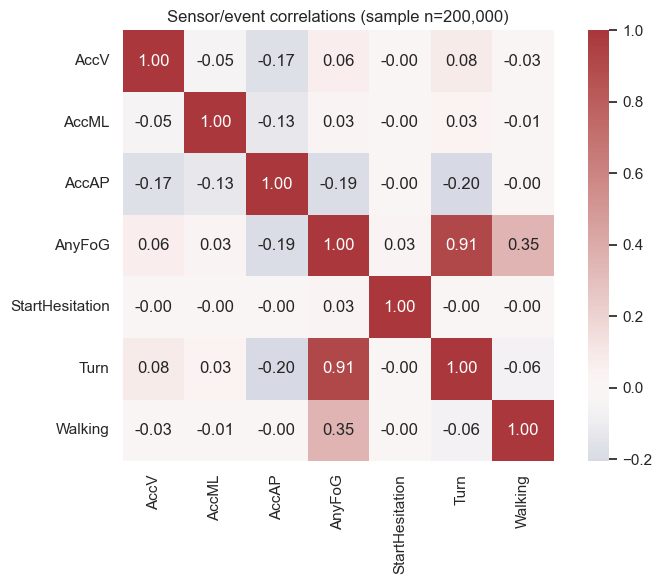

AccV     AccML     AccAP
target          state                              
AnyFoG          0     -0.937943 -0.002734 -0.205554
                1     -0.919382  0.007118 -0.331508
StartHesitation 0     -0.934824 -0.001077 -0.226710
                1     -0.943930 -0.011663 -0.254690
Turn            0     -0.938412 -0.002868 -0.206258
                1     -0.913423  0.009594 -0.348759
Walking         0     -0.934336 -0.000921 -0.226630
                1     -0.954437 -0.007399 -0.230063

,StartHesitation,Turn,Walking,rows
0,0,0,0,3404683
1,0,1,0,586829
2,0,0,1,98518
3,1,0,0,500


In [15]:
eda_sample = raw_data.sample(
    n=min(EDA_SAMPLE_SIZE, len(raw_data)),
    random_state=RANDOM_STATE,
)
correlation_columns = [*FEATURE_COLUMNS[:3], ANY_FOG_COLUMN, *TARGET_COLUMNS]
correlation_matrix = eda_sample.loc[:, correlation_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
)
plt.title(f"Sensor/event correlations (sample n={len(eda_sample):,})")
plt.tight_layout()
plt.show()

sensor_means = []
for target in (ANY_FOG_COLUMN, *TARGET_COLUMNS):
    grouped_means = eda_sample.groupby(target, observed=True)[list(FEATURE_COLUMNS[:3])].mean()
    grouped_means["target"] = target
    grouped_means["state"] = grouped_means.index.astype(int)
    sensor_means.append(grouped_means.reset_index(drop=True))
sensor_means = pd.concat(sensor_means, ignore_index=True)
display(sensor_means.set_index(["target", "state"]))

cooccurrence = raw_data.loc[:, TARGET_COLUMNS].value_counts().rename("rows").reset_index()
display(cooccurrence.head(10))

## Methods — subject-disjoint train, validation, and test splits

In [16]:
subject_splits = split_by_subject(
    raw_data,
    test_size=0.20,
    validation_size=0.20,
    random_state=RANDOM_STATE,
    require_all_targets=REQUIRE_ALL_TARGETS,
)
print("Selected split seed:", subject_splits.random_state)
split_summary(subject_splits)

Selected split seed: 46


,subjects,recordings,rows,StartHesitation_rate,Turn_rate,Walking_rate,AnyFoG_rate
split,,,,,,,
train,22,52,2458834,0.000092,0.147557,0.034482,0.182130
validation,8,21,792841,0.000114,0.102109,0.012824,0.115046
test,8,18,838855,0.000221,0.170537,0.004251,0.175009


## Checks — prove subjects and labels cannot leak

In [17]:
assert_subject_disjoint(subject_splits)
assert set(TARGET_COLUMNS).isdisjoint(FEATURE_COLUMNS)
assert ANY_FOG_COLUMN not in FEATURE_COLUMNS

print("Subjects are disjoint across train, validation, and test.")
print("Model features:", list(FEATURE_COLUMNS))
print("Primary target:", ANY_FOG_COLUMN)
print("Auxiliary event types:", list(TARGET_COLUMNS))

Subjects are disjoint across train, validation, and test.
Model features: ['AccV', 'AccML', 'AccAP', 'Rolling_AccV_Mean', 'Rolling_AccV_Std', 'Rolling_AccML_Mean', 'Rolling_AccML_Std', 'Rolling_AccAP_Mean', 'Rolling_AccAP_Std', 'Acc_Magnitude']
Primary target: AnyFoG
Auxiliary event types: ['StartHesitation', 'Turn', 'Walking']


,subjects,recordings,rows,StartHesitation_rate,Turn_rate,Walking_rate,AnyFoG_rate
split,,,,,,,
train,22,52,2458834,0.000092,0.147557,0.034482,0.182130
validation,8,21,792841,0.000114,0.102109,0.012824,0.115046
test,8,18,838855,0.000221,0.170537,0.004251,0.175009


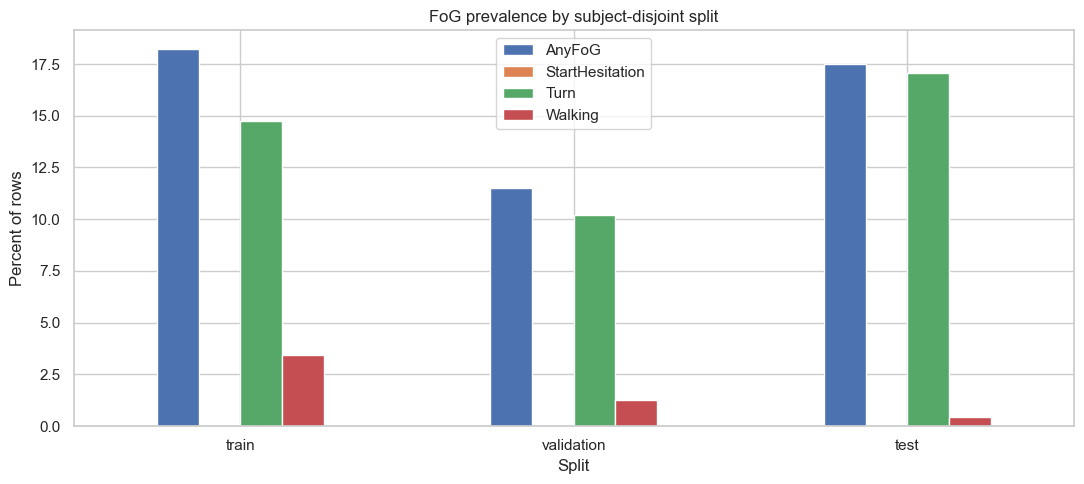

In [18]:
split_table = split_summary(subject_splits)
display(split_table)

rate_targets = [ANY_FOG_COLUMN, *TARGET_COLUMNS]
rate_columns = [f"{target}_rate" for target in rate_targets]
rate_plot = split_table.loc[:, rate_columns].rename(
    columns={f"{target}_rate": target for target in rate_targets}
) * 100
rate_plot.plot.bar(figsize=(11, 5))
plt.title("FoG prevalence by subject-disjoint split")
plt.ylabel("Percent of rows")
plt.xlabel("Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Features — fit imputation and scaling on training subjects only

In [19]:
del raw_data
gc.collect()
prepared = prepare_tabular_splits(
    subject_splits,
    window_size=WINDOW_SIZE,
)
del subject_splits
gc.collect()

pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "samples": [
            len(prepared.X_train),
            len(prepared.X_validation),
            len(prepared.X_test),
        ],
        "features": [
            prepared.X_train.shape[1],
            prepared.X_validation.shape[1],
            prepared.X_test.shape[1],
        ],
    }
)

,split,samples,features
0,train,2458834,10
1,validation,792841,10
2,test,838855,10


## Model — use validation subjects for training decisions

In [ ]:
model = None
history = None

if RUN_TRAINING:
    import tensorflow as tf

    tf.keras.utils.set_random_seed(RANDOM_STATE)
    fog_train = prepared.y_any_fog_train
    fog_validation = prepared.y_any_fog_validation
    fog_negatives = float((1.0 - fog_train).sum())
    fog_positives = float(fog_train.sum())
    fog_positive_weight = float(
        np.clip(fog_negatives / max(fog_positives, 1.0), 1.0, 200.0)
    )
    type_negatives = (1.0 - prepared.y_train).sum(axis=0)
    type_positives = prepared.y_train.sum(axis=0)
    type_positive_weights = np.clip(
        type_negatives / np.maximum(type_positives, 1.0), 1.0, 200.0
    )
    print(f"Any-FoG positive-class loss weight: {fog_positive_weight:.2f}")
    print(
        "Auxiliary event-type weights:",
        dict(zip(TARGET_COLUMNS, type_positive_weights.round(2))),
    )

    def make_weighted_binary_crossentropy(positive_weights):
        weights = tf.constant(positive_weights, dtype=tf.float32)

        def weighted_binary_crossentropy(y_true, y_pred):
            y_pred = tf.clip_by_value(
                y_pred,
                tf.keras.backend.epsilon(),
                1.0 - tf.keras.backend.epsilon(),
            )
            loss = -(
                weights * y_true * tf.math.log(y_pred)
                + (1.0 - y_true) * tf.math.log(1.0 - y_pred)
            )
            return tf.reduce_mean(loss)

        return weighted_binary_crossentropy

    inputs = tf.keras.layers.Input(shape=(len(FEATURE_COLUMNS),), name="sensor_features")
    shared = tf.keras.layers.Dense(128, activation="relu")(inputs)
    shared = tf.keras.layers.Dense(128, activation="relu")(shared)
    shared = tf.keras.layers.Dense(64, activation="relu")(shared)
    fog_output = tf.keras.layers.Dense(1, activation="sigmoid", name="fog")(shared)
    event_type_output = tf.keras.layers.Dense(
        len(TARGET_COLUMNS), activation="sigmoid", name="event_type"
    )(shared)
    model = tf.keras.Model(
        inputs=inputs,
        outputs={"fog": fog_output, "event_type": event_type_output},
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={
            "fog": make_weighted_binary_crossentropy(fog_positive_weight),
            "event_type": make_weighted_binary_crossentropy(type_positive_weights),
        },
        loss_weights={"fog": 1.0, "event_type": 0.2},
        metrics={
            "fog": [
                tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall"),
                tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            ],
            "event_type": [
                tf.keras.metrics.AUC(
                    curve="PR",
                    multi_label=True,
                    num_labels=len(TARGET_COLUMNS),
                    name="pr_auc",
                )
            ],
        },
    )
    history = model.fit(
        prepared.X_train,
        {"fog": fog_train, "event_type": prepared.y_train},
        validation_data=(
            prepared.X_validation,
            {"fog": fog_validation, "event_type": prepared.y_validation},
        ),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[
            
        ],
        verbose=2,
    )
else:
    print("Training is disabled. Set RUN_TRAINING=True after reviewing the split summary.")

Any-FoG positive-class loss weight: 4.49
Auxiliary event-type weights: {'StartHesitation': 200.0, 'Turn': 5.78, 'Walking': 28.0}
Epoch 1/40
601/601 - 7s - 12ms/step - event_type_loss: 0.8167 - event_type_pr_auc: 0.1095 - fog_binary_accuracy: 0.5935 - fog_loss: 1.0419 - fog_pr_auc: 0.2882 - fog_precision: 0.2685 - fog_recall: 0.7145 - loss: 1.2052 - val_event_type_loss: 0.6914 - val_event_type_pr_auc: 0.0444 - val_fog_binary_accuracy: 0.4594 - val_fog_loss: 0.9769 - val_fog_pr_auc: 0.1344 - val_fog_precision: 0.1446 - val_fog_recall: 0.7528 - val_loss: 1.1144
Epoch 2/40
601/601 - 5s - 8ms/step - event_type_loss: 0.7643 - event_type_pr_auc: 0.1200 - fog_binary_accuracy: 0.6041 - fog_loss: 1.0167 - fog_pr_auc: 0.3079 - fog_precision: 0.2784 - fog_recall: 0.7372 - loss: 1.1695 - val_event_type_loss: 0.7086 - val_event_type_pr_auc: 0.0440 - val_fog_binary_accuracy: 0.4547 - val_fog_loss: 0.9867 - val_fog_pr_auc: 0.1416 - val_fog_precision: 0.1457 - val_fog_recall: 0.7686 - val_loss: 1.1276


### Learning curves

,event_type_loss,event_type_pr_auc,fog_binary_accuracy,fog_loss,fog_pr_auc,fog_precision,fog_recall,loss,val_event_type_loss,val_event_type_pr_auc,val_fog_binary_accuracy,val_fog_loss,val_fog_pr_auc,val_fog_precision,val_fog_recall,val_loss
0,0.816702,0.109481,0.593503,1.041896,0.288242,0.268513,0.714477,1.205168,0.691433,0.044415,0.459381,0.976881,0.134449,0.144633,0.752776,1.114407
1,0.764263,0.119993,0.604092,1.016729,0.307864,0.278385,0.737222,1.169528,0.708591,0.043968,0.454712,0.986663,0.141635,0.145656,0.768629,1.127637
2,0.745284,0.132845,0.626375,0.990292,0.341166,0.290054,0.726303,1.139288,0.709098,0.044921,0.476533,0.987391,0.138996,0.143039,0.711280,1.128345
3,0.730179,0.145656,0.637893,0.973556,0.368137,0.296855,0.722015,1.119522,0.709699,0.046967,0.482927,0.985359,0.141813,0.141642,0.690603,1.126378
4,0.719408,0.155300,0.649866,0.962898,0.385221,0.303790,0.714106,1.106705,0.710455,0.048575,0.500971,0.978113,0.146673,0.143071,0.668929,1.119287
5,0.712035,0.162473,0.662634,0.954061,0.399191,0.311672,0.705286,1.096395,0.705071,0.051102,0.523862,0.959768,0.152610,0.147065,0.653931,1.099854
6,0.706167,0.168784,0.674072,0.945564,0.411469,0.319440,0.698410,1.086724,0.702515,0.052230,0.533770,0.952165,0.154334,0.149580,0.651508,1.091736
7,0.701721,0.172322,0.680634,0.939583,0.419262,0.324221,0.694918,1.079856,0.700593,0.053094,0.542361,0.946781,0.156563,0.150913,0.643680,1.085934
8,0.698179,0.174803,0.684760,0.935102,0.425069,0.327385,0.693073,1.074673,0.703028,0.053097,0.546366,0.950436,0.156704,0.151537,0.639931,1.090113
9,0.695078,0.176837,0.687996,0.931394,0.429969,0.329851,0.691191,1.070349,0.701733,0.053385,0.553382,0.947735,0.158336,0.151029,0.623661,1.087128


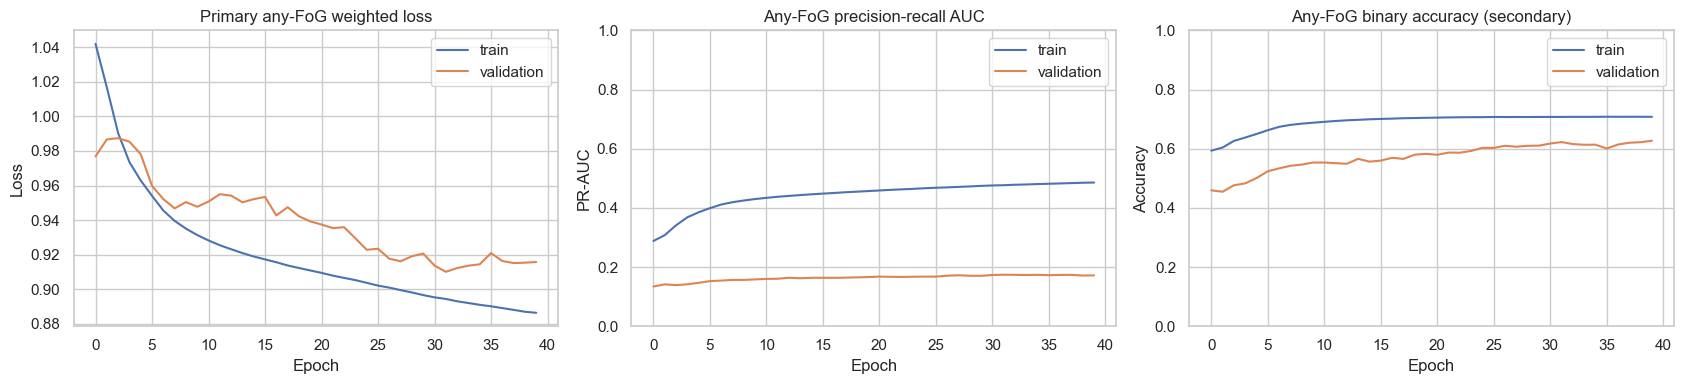

In [21]:
if history is not None:
    history_frame = pd.DataFrame(history.history)
    display(history_frame)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(history_frame["fog_loss"], label="train")
    axes[0].plot(history_frame["val_fog_loss"], label="validation")
    axes[0].set_title("Primary any-FoG weighted loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_frame["fog_pr_auc"], label="train")
    axes[1].plot(history_frame["val_fog_pr_auc"], label="validation")
    axes[1].set_title("Any-FoG precision-recall AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PR-AUC")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    axes[2].plot(history_frame["fog_binary_accuracy"], label="train")
    axes[2].plot(
        history_frame["val_fog_binary_accuracy"], label="validation"
    )
    axes[2].set_title("Any-FoG binary accuracy (secondary)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy")
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Learning curves are unavailable because training is disabled.")

## Final test — detect complete FoG episodes once

Validation-selected any-FoG threshold: 0.10


,threshold,episode_precision,episode_recall,episode_f1,false_alarms_per_minute,mean_duration_iou,true_episodes,predicted_episodes,matched_episodes
0,0.05,0.007790,0.295652,0.015180,65.544037,0.467888,230,8729,68
1,0.10,0.012737,0.504348,0.024847,68.041385,0.485523,230,9107,116
2,0.15,0.011697,0.634783,0.022970,93.355414,0.477038,230,12482,146
3,0.20,0.009740,0.686957,0.019207,121.567881,0.485985,230,16222,158
4,0.25,0.007895,0.695652,0.015612,152.164179,0.469000,230,20267,160
5,0.30,0.005812,0.621739,0.011516,185.129175,0.463273,230,24606,143
6,0.35,0.004433,0.556522,0.008796,217.534159,0.426069,230,28873,128
7,0.40,0.002768,0.386957,0.005497,242.621156,0.416056,230,32149,89
8,0.45,0.001640,0.234783,0.003258,248.728307,0.409688,230,32921,54
9,0.50,0.001422,0.182609,0.002822,223.232653,0.427767,230,29540,42


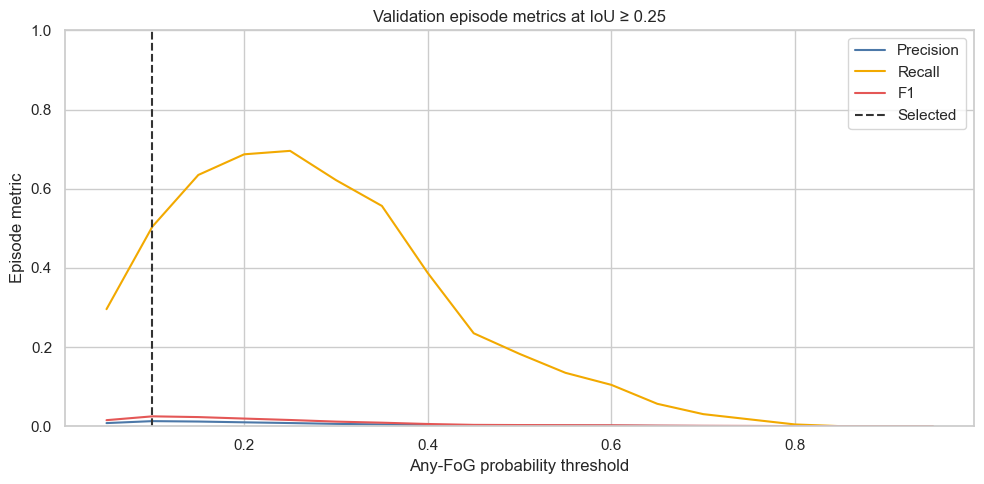

,fog_loss,any_fog_prevalence,average_precision,balanced_accuracy,precision,recall,f1
split,,,,,,,
train,0.890903,0.182130,0.484716,0.576928,0.208453,0.996485,0.344782
validation,0.910126,0.115046,0.174213,0.572890,0.132174,0.995549,0.233365
test,1.049399,0.175009,0.242823,0.602930,0.211661,0.980764,0.348180


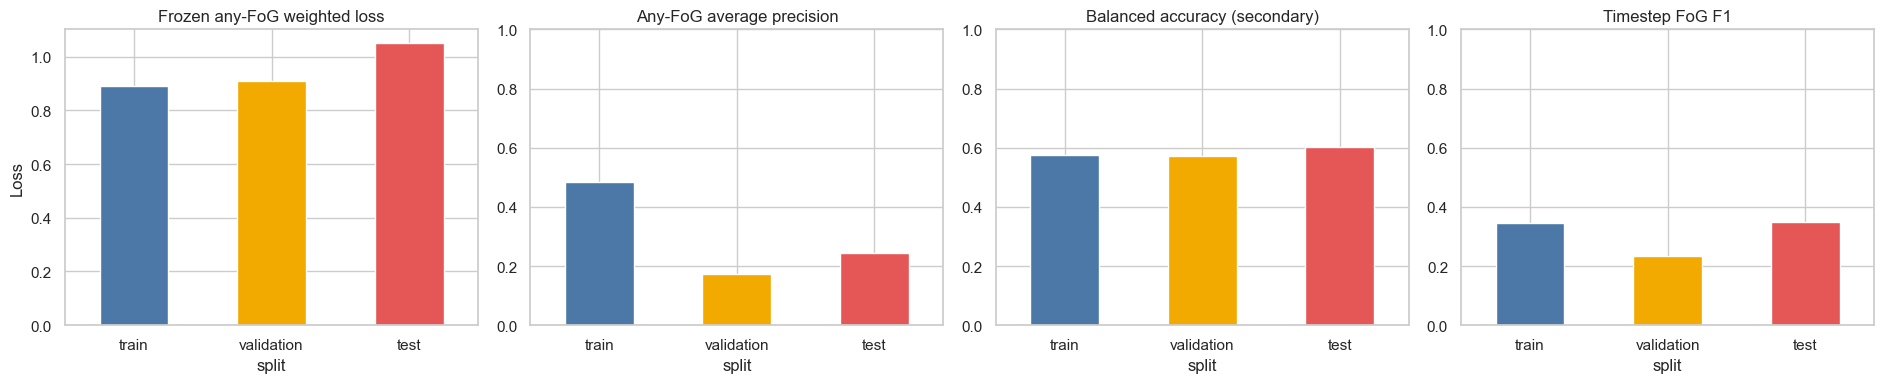

,held_out_test
threshold_selected_on_validation,0.100000
positive_prevalence,0.175009
average_precision,0.242823
balanced_accuracy,0.602930
precision,0.211661
recall,0.980764
f1,0.348180


,held_out_test
true_episodes,278.000000
predicted_episodes,8272.000000
matched_episodes,113.000000
false_positive_episodes,8159.000000
missed_episodes,165.000000
episode_precision,0.013661
episode_recall,0.406475
episode_f1,0.026433
false_alarms_per_minute,58.358119
mean_onset_delay_seconds,-2.012124


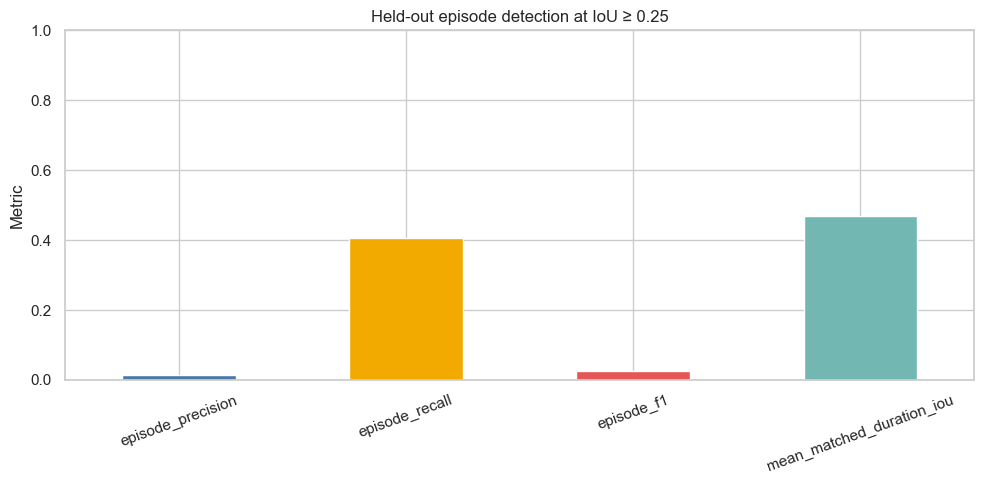

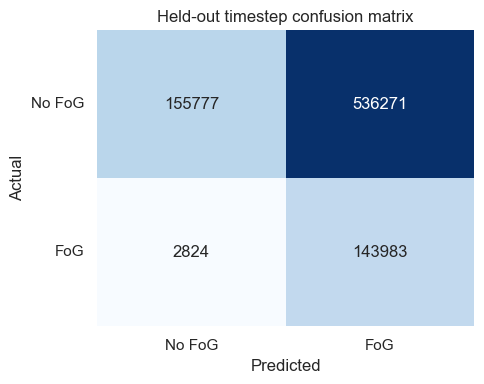

,threshold,positive_prevalence,average_precision,precision,recall,f1
target,,,,,,
StartHesitation,0.004757,0.000221,0.000170,0.000156,0.351351,0.000312
Turn,0.261362,0.170537,0.247738,0.241076,0.875021,0.378008
Walking,0.504419,0.004251,0.008834,0.008835,0.663489,0.017437


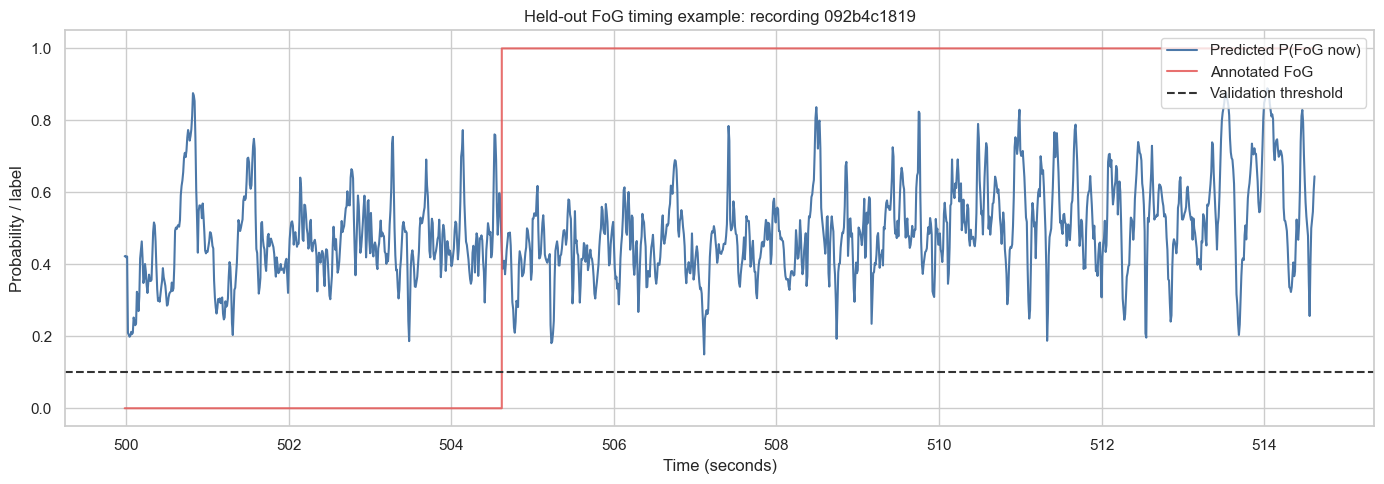

In [22]:
if model is not None:
    from sklearn.metrics import (
        average_precision_score,
        balanced_accuracy_score,
        confusion_matrix,
        f1_score,
        precision_recall_curve,
        precision_score,
        recall_score,
    )

    def unpack_model_outputs(outputs):
        if isinstance(outputs, dict):
            return outputs["fog"], outputs["event_type"]
        output_by_name = dict(zip(model.output_names, outputs))
        return output_by_name["fog"], output_by_name["event_type"]

    validation_outputs = model.predict(
        prepared.X_validation,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    validation_fog_probabilities, validation_type_probabilities = unpack_model_outputs(
        validation_outputs
    )
    decision_threshold, threshold_search = select_episode_threshold(
        prepared.alignment_splits.validation,
        prepared.y_any_fog_validation,
        validation_fog_probabilities,
        sampling_rate_hz=SAMPLING_RATE_HZ,
        thresholds=np.linspace(0.05, 0.95, 19),
        minimum_iou=EPISODE_IOU_THRESHOLD,
        merge_gap_seconds=MERGE_GAP_SECONDS,
        minimum_predicted_duration_seconds=MIN_PREDICTED_EPISODE_SECONDS,
    )
    print(f"Validation-selected any-FoG threshold: {decision_threshold:.2f}")
    display(threshold_search)

    plt.figure(figsize=(10, 5))
    for metric, colour in (
        ("episode_precision", "#4c78a8"),
        ("episode_recall", "#f2a900"),
        ("episode_f1", "#e45756"),
    ):
        plt.plot(
            threshold_search["threshold"],
            threshold_search[metric],
            label=metric.replace("episode_", "").title(),
            color=colour,
        )
    plt.axvline(decision_threshold, color="#333333", linestyle="--", label="Selected")
    plt.title(f"Validation episode metrics at IoU ≥ {EPISODE_IOU_THRESHOLD:.2f}")
    plt.xlabel("Any-FoG probability threshold")
    plt.ylabel("Episode metric")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Freeze the model and validation-selected threshold before examining test.
    split_evaluations = []
    split_probabilities = {}
    for split_name, X_values, y_fog_values, y_type_values in (
        ("train", prepared.X_train, prepared.y_any_fog_train, prepared.y_train),
        (
            "validation",
            prepared.X_validation,
            prepared.y_any_fog_validation,
            prepared.y_validation,
        ),
        ("test", prepared.X_test, prepared.y_any_fog_test, prepared.y_test),
    ):
        evaluation = model.evaluate(
            X_values,
            {"fog": y_fog_values, "event_type": y_type_values},
            batch_size=BATCH_SIZE,
            return_dict=True,
            verbose=0,
        )
        outputs = model.predict(X_values, batch_size=BATCH_SIZE, verbose=0)
        fog_probabilities, type_probabilities = unpack_model_outputs(outputs)
        split_probabilities[split_name] = (fog_probabilities, type_probabilities)
        fog_true = y_fog_values.reshape(-1)
        fog_score = fog_probabilities.reshape(-1)
        fog_predicted = (fog_score >= decision_threshold).astype(np.int8)
        split_evaluations.append(
            {
                "split": split_name,
                "fog_loss": evaluation["fog_loss"],
                "any_fog_prevalence": fog_true.mean(),
                "average_precision": average_precision_score(fog_true, fog_score),
                "balanced_accuracy": balanced_accuracy_score(
                    fog_true, fog_predicted
                ),
                "precision": precision_score(
                    fog_true, fog_predicted, zero_division=0
                ),
                "recall": recall_score(fog_true, fog_predicted, zero_division=0),
                "f1": f1_score(fog_true, fog_predicted, zero_division=0),
            }
        )

    split_evaluation_frame = pd.DataFrame(split_evaluations).set_index("split")
    display(split_evaluation_frame)
    split_colours = ["#4c78a8", "#f2a900", "#e45756"]
    fig, axes = plt.subplots(1, 4, figsize=(19, 4))
    split_evaluation_frame["fog_loss"].plot.bar(ax=axes[0], color=split_colours)
    axes[0].set_title("Frozen any-FoG weighted loss")
    axes[0].set_ylabel("Loss")
    axes[0].tick_params(axis="x", rotation=0)
    for axis, metric, title in (
        (axes[1], "average_precision", "Any-FoG average precision"),
        (axes[2], "balanced_accuracy", "Balanced accuracy (secondary)"),
        (axes[3], "f1", "Timestep FoG F1"),
    ):
        split_evaluation_frame[metric].plot.bar(ax=axis, color=split_colours)
        axis.set_title(title)
        axis.set_ylim(0, 1)
        axis.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    test_fog_probabilities, test_type_probabilities = split_probabilities["test"]
    test_fog_true = prepared.y_any_fog_test.reshape(-1)
    test_fog_score = test_fog_probabilities.reshape(-1)
    test_fog_predictions = (test_fog_score >= decision_threshold).astype(np.int8)
    point_metrics = pd.Series(
        {
            "threshold_selected_on_validation": decision_threshold,
            "positive_prevalence": test_fog_true.mean(),
            "average_precision": average_precision_score(
                test_fog_true, test_fog_score
            ),
            "balanced_accuracy": balanced_accuracy_score(
                test_fog_true, test_fog_predictions
            ),
            "precision": precision_score(
                test_fog_true, test_fog_predictions, zero_division=0
            ),
            "recall": recall_score(
                test_fog_true, test_fog_predictions, zero_division=0
            ),
            "f1": f1_score(test_fog_true, test_fog_predictions, zero_division=0),
        },
        name="held_out_test",
    )
    display(point_metrics.to_frame())

    episode_evaluation = evaluate_episode_predictions(
        prepared.alignment_splits.test,
        prepared.y_any_fog_test,
        test_fog_probabilities,
        threshold=decision_threshold,
        sampling_rate_hz=SAMPLING_RATE_HZ,
        minimum_iou=EPISODE_IOU_THRESHOLD,
        merge_gap_seconds=MERGE_GAP_SECONDS,
        minimum_predicted_duration_seconds=MIN_PREDICTED_EPISODE_SECONDS,
    )
    episode_metrics = pd.Series(
        {
            "true_episodes": episode_evaluation.true_count,
            "predicted_episodes": episode_evaluation.predicted_count,
            "matched_episodes": episode_evaluation.true_positive_count,
            "false_positive_episodes": episode_evaluation.false_positive_count,
            "missed_episodes": episode_evaluation.false_negative_count,
            "episode_precision": episode_evaluation.precision,
            "episode_recall": episode_evaluation.recall,
            "episode_f1": episode_evaluation.f1,
            "false_alarms_per_minute": episode_evaluation.false_alarms_per_minute,
            "mean_onset_delay_seconds": episode_evaluation.mean_onset_delay_seconds,
            "median_onset_delay_seconds": episode_evaluation.median_onset_delay_seconds,
            "mean_absolute_onset_error_seconds": episode_evaluation.mean_absolute_onset_error_seconds,
            "mean_matched_duration_iou": episode_evaluation.mean_duration_iou,
            "evaluated_minutes": episode_evaluation.evaluation_minutes,
        },
        name="held_out_test",
    )
    display(episode_metrics.to_frame())

    episode_bar_values = episode_metrics.loc[
        [
            "episode_precision",
            "episode_recall",
            "episode_f1",
            "mean_matched_duration_iou",
        ]
    ]
    ax = episode_bar_values.plot.bar(
        figsize=(10, 5),
        color=["#4c78a8", "#f2a900", "#e45756", "#72b7b2"],
    )
    ax.set_title(f"Held-out episode detection at IoU ≥ {EPISODE_IOU_THRESHOLD:.2f}")
    ax.set_ylabel("Metric")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    matrix = confusion_matrix(
        test_fog_true,
        test_fog_predictions,
        labels=[0, 1],
    )
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Held-out timestep confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["No FoG", "FoG"])
    plt.yticks([0.5, 1.5], ["No FoG", "FoG"], rotation=0)
    plt.tight_layout()
    plt.show()

    # Event type remains an auxiliary description, not the primary objective.
    type_thresholds = []
    type_metric_rows = []
    for target_index, target in enumerate(TARGET_COLUMNS):
        validation_precision, validation_recall, candidate_thresholds = precision_recall_curve(
            prepared.y_validation[:, target_index],
            validation_type_probabilities[:, target_index],
        )
        validation_f1 = (
            2
            * validation_precision[:-1]
            * validation_recall[:-1]
            / np.maximum(
                validation_precision[:-1] + validation_recall[:-1], 1e-12
            )
        )
        type_threshold = float(
            candidate_thresholds[int(np.nanargmax(validation_f1))]
        )
        type_thresholds.append(type_threshold)
        y_true = prepared.y_test[:, target_index]
        y_score = test_type_probabilities[:, target_index]
        y_pred = (y_score >= type_threshold).astype(np.int8)
        type_metric_rows.append(
            {
                "target": target,
                "threshold": type_threshold,
                "positive_prevalence": y_true.mean(),
                "average_precision": average_precision_score(y_true, y_score),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    display(pd.DataFrame(type_metric_rows).set_index("target"))

    # Fixed-rule example: first held-out recording containing an annotated FoG row.
    aligned_test = align_binary_predictions(
        prepared.alignment_splits.test,
        prepared.y_any_fog_test,
        test_fog_probabilities,
        threshold=decision_threshold,
        sampling_rate_hz=SAMPLING_RATE_HZ,
    )
    recording_totals = aligned_test.groupby(
        "RecordingId", observed=True
    )["AnyFoGTrue"].sum()
    positive_recordings = sorted(
        recording_totals.loc[recording_totals > 0].index,
        key=str,
    )
    if positive_recordings:
        example_recording_id = positive_recordings[0]
        example = aligned_test.loc[
            aligned_test["RecordingId"] == example_recording_id
        ].sort_values("TimeSeconds", kind="stable")
        first_positive_time = float(
            example.loc[example["AnyFoGTrue"] == 1, "TimeSeconds"].iloc[0]
        )
        example_window = example.loc[
            example["TimeSeconds"].between(
                max(0.0, first_positive_time - 5.0),
                first_positive_time + 10.0,
            )
        ]

        fig, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            example_window["TimeSeconds"],
            example_window["AnyFoGScore"],
            color="#4c78a8",
            label="Predicted P(FoG now)",
        )
        axis.step(
            example_window["TimeSeconds"],
            example_window["AnyFoGTrue"],
            where="post",
            color="#e45756",
            alpha=0.85,
            label="Annotated FoG",
        )
        axis.axhline(
            decision_threshold,
            color="#333333",
            linestyle="--",
            label="Validation threshold",
        )
        axis.set_title(
            f"Held-out FoG timing example: recording {example_recording_id}"
        )
        axis.set_xlabel("Time (seconds)")
        axis.set_ylabel("Probability / label")
        axis.set_ylim(-0.05, 1.05)
        axis.legend(loc="upper right")
        plt.tight_layout()
        plt.show()
    else:
        print("No positive held-out recording was available for a timing example.")
else:
    print("No final test evaluation was run because training is disabled.")

## Takeaways

- Rows from a subject can occur in only one split.
- Rolling features reset at recording boundaries.
- Inputs contain accelerometer-derived values only.
- The imputer and scaler learn from training subjects only.
- The test subjects are not used for early stopping or model selection.
- The validation split selects the FoG probability threshold; test
  episodes are then scored by one-to-one temporal overlap.